# IceCube Event Classification with Machine Learning

## Introduction

The IceCube Neutrino Observatory is a cubic-kilometer-scale detector located at the South Pole,
designed to detect high-energy neutrinos through the Cherenkov light emitted by secondary
charged particles produced in neutrino interactions within the Antarctic ice. By reconstructing
the properties of these light patterns, IceCube enables the study of neutrino sources and
fundamental neutrino properties, including neutrino oscillations. The classification of
neutrino-induced events against atmospheric background is therefore a crucial step in the
analysis chain, directly motivating the application of machine learning techniques in this
project.

The objective of this project is the classification of neutrino-induced events (signal)
and atmospheric muons (background) using multivariate machine learning techniques.
Three classifiers are considered: Naive Bayes, k-Nearest Neighbors, and Random Forest.
Model performance is evaluated using 10-fold cross-validation and assessed through
accuracy, precision, recall, ROC curves, and the $f_{\beta}$-score.


## Setup

In [40]:
# Import standard libraries for machine learning and metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# Aesthetics for plots

plt.rcParams.update({
    'legend.frameon': False,
    'legend.fontsize': 'xx-large',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'lines.linewidth': 2.5,
    'figure.figsize': (8, 6)
})

## Quality Parameters

To evaluate the performance of the machine learning models applied to IceCube Monte Carlo
data for the study of neutrino oscillations, several quality parameters derived from the
confusion matrix were used. Each event is classified either as signal (neutrino) or
background (atmospheric muon), leading to true positives (tp), true negatives (tn),
false positives (fp), and false negatives (fn).

The main classification metrics considered were precision and recall, defined as:

$$
p = \frac{tp}{tp + fp}
$$

$$
r = \frac{tp}{tp + fn}
$$

To select the optimal classification threshold $\tau_c$, the $f_{\beta}$-score was used with
$\beta = 0.1$, giving higher importance to precision in order to reduce background
contamination:

$$
f_{\beta} = \frac{(1 + \beta^2)\, p \cdot r}{\beta^2\, p + r}
$$

Additionally, the Receiver Operating Characteristic (ROC) curve was constructed by
evaluating the True Positive Rate (TPR) and False Positive Rate (FPR) as functions of the
classification threshold:

$$
\mathrm{TPR}(\tau_c) = \frac{tp(\tau_c)}{tp(\tau_c) + fn(\tau_c)}
$$

$$
\mathrm{FPR}(\tau_c) = \frac{fp(\tau_c)}{fp(\tau_c) + tn(\tau_c)}
$$

The Area Under the ROC Curve (AROC) was used as a global performance metric to compare
different classifiers, where values close to 1 indicate strong separation between signal and
background events.

### Quality Metrics Implementation

The following functions implement the quality parameters used to evaluate the performance
of the classification models. Metrics are computed directly from the confusion matrix and
are used both for threshold optimization and for ROC curve construction. The $f_{\beta}$
score is evaluated with $\beta = 0.1$ in order to prioritize precision over recall, which is
particularly relevant for reducing background contamination in neutrino event selection.

In [41]:
def quality_parameters(cm):
    """
    Compute precision, recall, and F-beta score from a confusion matrix.
    
    Args:
        cm (array-like): Confusion matrix in the format:
                         [[TN, FP],
                          [FN, TP]]
    
    Returns:
        tuple: (precision, recall, f_beta) with beta = 0.1
    """
    beta = 0.1
    precision = cm[1][1] / (cm[1][1] + cm[0][1])
    recall = cm[1][1] / (cm[1][1] + cm[1][0])
    f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    return precision, recall, f_beta

def fbeta_evolution(p, r):
    """
    Compute F-beta score given arrays of precision and recall.

    Args:
        p (array-like): Precision values
        r (array-like): Recall values

    Returns:
        array-like: Corresponding F-beta scores
    """
    beta = 0.1
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)


def punto_fb(cm):
    """
    Compute the ROC point (FPR, TPR) from confusion matrix.

    Args:
        cm (array-like): Confusion matrix

    Returns:
        tuple: (false positive rate, true positive rate)
    """
    tpr = cm[1][1] / (cm[1][1] + cm[1][0])
    fpr = cm[0][1] / (cm[0][1] + cm[0][0])
    return fpr, tpr

## Load Dataset 

In [42]:
# Load background and signal train datasets 

data_background_train = pd.read_csv("./data/background_train.csv")
data_signal_train = pd.read_csv("./data/signal_train.csv")
print("Data Information:")
print(f"Background data shape = {data_background_train.shape}")
print(f"Signal data shape = {data_signal_train.shape}")


# Combine background and signal into a single train dataset

data_train = pd.concat([data_background_train, data_signal_train], ignore_index=True)
print(f"Data shape before IDs removal = {data_train.shape}")

Data Information:
Background data shape = (18067, 283)
Signal data shape = (17933, 283)
Data shape before IDs removal = (36000, 283)


## Preprocess  Dataset 

In [43]:
# Remove columns of Monte Carlo truth info and IDs based on name patterns (not features)

columns_to_remove = [col for col in data_train.columns if any(keyword in col for keyword in ['Weight', 'MC', 'Corsika', 'ID', 'I3EventHeader'])]
data_train.drop(columns=columns_to_remove, inplace=True)
print(f"Data shape after IDs removal = {data_train.shape}")


# Check for infinite values in df

inf_count = data_train.isin([np.inf, -np.inf]).sum().sum()
print("\nData preprocessing information:")
print(f"Total infinite values in dataset = {inf_count}")


# Check for None values in df 

missing_total = data_train.isnull()#.sum().sum()
print("Number of NaN, None values per column (only columns with at least one missing value):")
print(missing_total.sum()[missing_total.sum() > 0])
print(f"Total missing values in dataset = {missing_total.sum().sum()}")
data_train.fillna(0, inplace=True)  # Fill missing values with 0

Data shape after IDs removal = (36000, 188)

Data preprocessing information:
Total infinite values in dataset = 0
Number of NaN, None values per column (only columns with at least one missing value):
LineFit_TT.energy                                             36000
LineFit_TT.length                                             36000
MPEFitHighNoise.energy                                        36000
MPEFitHighNoise.length                                        36000
MPEFitHighNoiseFitParams.logl                                     6
MPEFitHighNoiseFitParams.rlogl                                    6
MPEFitParaboloid.length                                       36000
MPEFit_TT.x                                                       4
MPEFit_TT.y                                                       4
MPEFit_TT.z                                                       4
MPEFit_TT.time                                                    4
MPEFit_TT.zenith                                    

## Attribute Selection

In [44]:
# Define features and labels

X = data_train.drop(columns=["label"])
y = data_train["label"]


# Select relevant features using Minimum Redundancy Maximum Relevance (mRMR)

from mrmr import mrmr_classif
max_features = 12     # maximum number of features selected
selected_features_mrmr = mrmr_classif(X=X, y=y, K=max_features)
#print(f"Selected features (mRMR): {selected_features_mrmr}")
print(f"\nFinal data shape after attribute selection = {X[selected_features_mrmr].shape}")


# Split dataset for training and validation using only thr selected features

X_train, X_val, y_train, y_val = train_test_split(X[selected_features_mrmr], y, test_size=0.3, random_state=132)
print(f"Data shape (train) = {X_train.shape}")
print(f"Target shape (train) = {y_train.shape}")
print(f"Data shape (validation) = {X_val.shape}")
print(f"Target shape (validation) = {y_val.shape}")
X_train.head()

100%|█████████████████████████████████████████████████████████████████████████| 12/12 [00:02<00:00,  4.96it/s]


Final data shape after attribute selection = (36000, 12)
Data shape (train) = (25200, 12)
Target shape (train) = (25200,)
Data shape (validation) = (10800, 12)
Target shape (validation) = (10800,)


,LineFit_TTParams.lf_vel_z,SplineMPEDirectHitsC.n_dir_strings,HitStatisticsValues.z_travel,SplineMPEFitParams.rlogl,SplineMPEDirectHitsA.dir_track_length,LineFit_TT.zenith,SplineMPEDirectHitsA.n_dir_strings,MuEXAngular4.zenith,MuEXAngular4_Sigma.value,MPEFitHighNoise.zenith,SplineMPEDirectHitsA.n_dir_doms,SplineMPE.zenith
13776,0.051325,4.0,24.819072,9.082065,221.736758,1.914624,3.0,1.609274,0.159333,2.253015,7.0,1.561127
13939,0.022755,3.0,3.956665,8.808967,4.097016,1.678642,1.0,1.665757,0.058019,1.703958,3.0,1.691448
30394,0.171891,5.0,104.713333,8.168227,3.238439,2.113804,2.0,2.033587,0.113798,2.012800,2.0,2.006044
28487,0.137467,10.0,69.705417,6.522150,389.768405,2.045040,7.0,2.097315,0.013886,2.090306,20.0,2.101975
25910,0.117705,2.0,65.121058,11.491308,0.000000,2.085281,1.0,2.092016,0.081191,2.144950,1.0,2.132661


### Training and Validation Funtion Declaration

Three classifiers are considered: Naive Bayes (NB), k-Nearest Neighbors (kNN), and Random Forest (RF).

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Declare a function to train and validate the selected model

def model_train_evaluate(model_name: str, X_train, y_train, X_val, y_val, is_test: False):

    """
    Train and evaluate a classification model (NB, RF or kNN).
    """
    test = "validation"
    if is_test == True:
        test = "test"

    
    # Initialize model based on selected algorithm
    
    if model_name == "NB" :
        model = GaussianNB()
        name = "Gaussian Naïve Bayes" 
        
    elif model_name == "RF":
        model = RandomForestClassifier(n_estimators = 100, random_state = 132)
        name = "Random Forest"
    
    elif model_name == "kNN":
        # Scaling is required for distance-based models
        model = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
        name = "k-Nearest Neighbors"

    else:
        raise ValueError("Not Supported Model. Use 'NB', 'RF' or 'kNN'")

    
    # Train
    
    model.fit(X_train, y_train)

    
    # Predict labels and probabilities
    
    y_predicted = model.predict(X_val)
    y_predicted_probability = model.predict_proba(X_val)[:, 1]

    
    # Compute confusion matrix
    
    conf_matrix = confusion_matrix(y_val, y_predicted)
    plt.figure()
    plt.title(f"{name} - Confusion Matrix ({test})") # Plot confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"confusion_matrix_{model_name}_{test}.png", dpi = 150)
    plt.show()

    
    # Compute quality metrics: 
    
    accuracy = accuracy_score(y_val, y_predicted)  # accuracy
    precision, recall, fbeta = quality_parameters(conf_matrix)  # precision, recall, and F-beta
    print(f"\nClassification Report [{name}] ({test}):")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"f-beta: {fbeta:.2f}")


    # Compute ROC curve

    fpr, tpr, _ = roc_curve(y_val, y_predicted_probability)
    roc_auc = roc_auc_score(y_val, y_predicted_probability)


    # Plot ROC curve

    plt.figure(figsize=(16,6))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='k')
    x_opt, y_opt = punto_fb(conf_matrix)
    plt.plot(x_opt, y_opt, 'ro', lw=2, label='Optimal Threshold')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve - {name} ({test})')
    plt.legend(loc='lower right')
    plt.grid(True)


    # Plot Precision and Recall vs threshold

    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_predicted_probability) # Compute Precision-Recall curve

    plt.subplot(1,2,2)
    plt.plot(thresholds, precision_curve[:-1], label="Precision")
    plt.plot(thresholds, recall_curve[:-1], label="Recall")
    # Compute optimal threshold as point where precision ≈ recall
    opt_t = thresholds[np.argmin(np.abs(recall_curve[:-1] - precision_curve[:-1]))]
    plt.axvline(x=opt_t, color='r', linestyle=':', label=f'Optimal threshold (τ={opt_t:.4f})')
    plt.xlabel(r"Threshold ($\tau$)")
    plt.ylabel("Score")
    plt.title(f"Quality Parameters - {name} ({test})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"ROC_and_presicion_recall_{model_name}_{test}.png", dpi = 150)
    plt.show()


    return model

### Cross-Validation Function Declaration

In [46]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer

def model_cross_validation(model, number_folds: int, X_train, y_train):

    # Define number of folds for K-Fold Cross-Validation
    
    k = number_folds      # 2000 was likely excessive and computationally expensive
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    
    # Compute standard cross-validated scores
    
    accuracy_scores  = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    precision_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='precision')
    recall_scores    = cross_val_score(model, X_train, y_train, cv=kf, scoring='recall')
    roc_auc_scores   = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc')


    # Compute F-beta scores with beta = 0.1
    f_beta_scores = fbeta_evolution(precision_scores, recall_scores)

    # Compute Standard Error of the Mean (SEM) for each metric
    def sem(scores):
        return np.std(scores) / np.sqrt(len(scores))

    # Print average and SEM for all metrics
    print("[Cross-Validation Results]")
    print(f"Average Accuracy:     {accuracy_scores.mean():.4f} ± {sem(accuracy_scores):.4f}")
    print(f"Average Precision:    {precision_scores.mean():.4f} ± {sem(precision_scores):.4f}")
    print(f"Average Recall:       {recall_scores.mean():.4f} ± {sem(recall_scores):.4f}")
    print(f"Average ROC AUC:      {roc_auc_scores.mean():.4f} ± {sem(roc_auc_scores):.4f}")
    print(f"Average F-beta (β=0.1): {f_beta_scores.mean():.4f} ± {sem(f_beta_scores):.4f}")

    return

# Training - Validation - Evaluation

## Gaussian Naïve Bayes (NB)

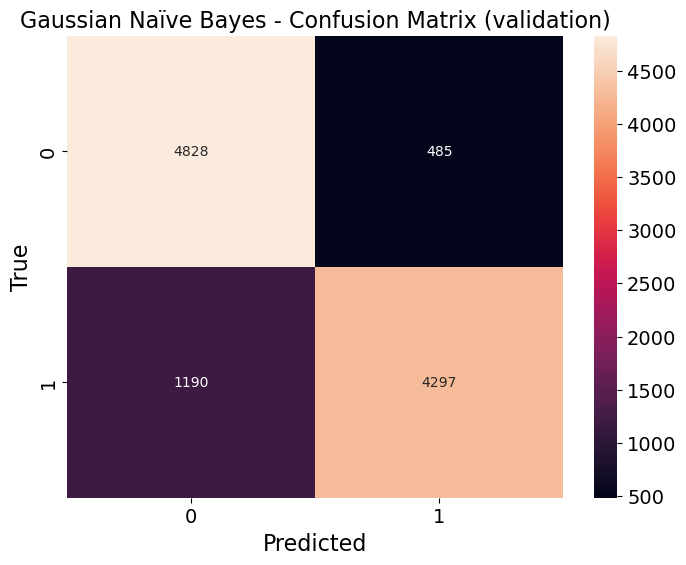


Classification Report [Gaussian Naïve Bayes] (validation):
Accuracy: 0.84
Precision: 0.90
Recall: 0.78
f-beta: 0.90


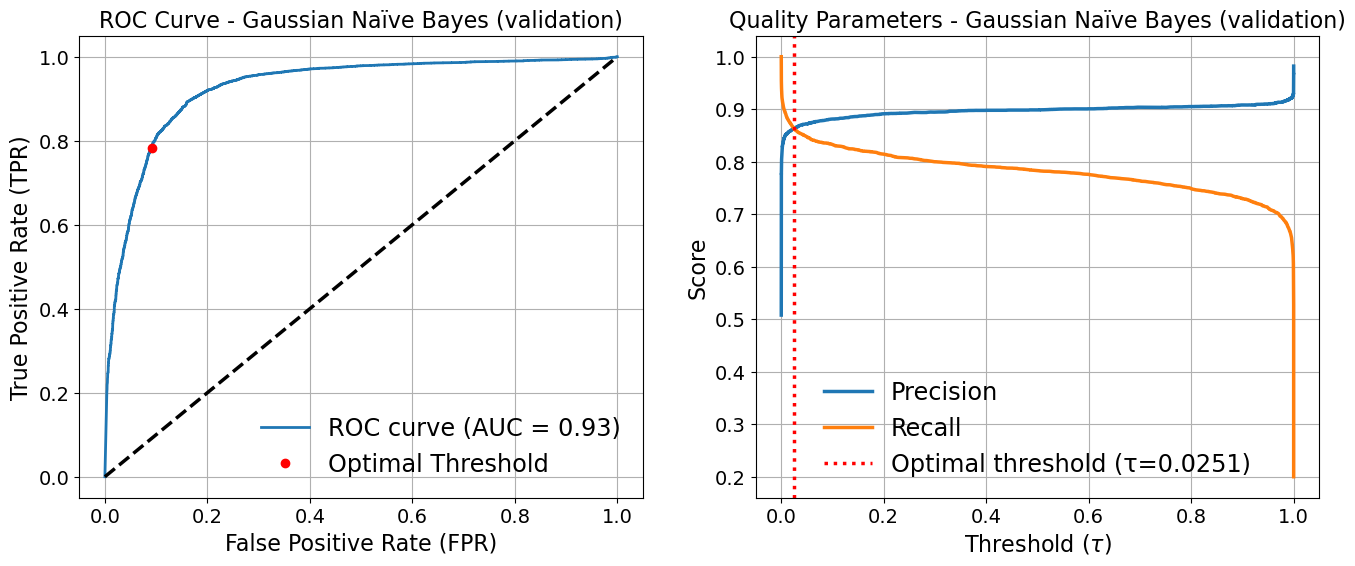

In [47]:
# Training and evaluation of Naive Bayes 

model_name = "NB"
model = model_train_evaluate(model_name, X_train, y_train, X_val, y_val, False)

### NB Cross Validation

In [48]:
# Cross validation with kf folds and model
kf = 10
model_cross_validation(GaussianNB(), kf, X_train, y_train)

[Cross-Validation Results]
Average Accuracy:     0.8430 ± 0.0015
Average Precision:    0.8874 ± 0.0030
Average Recall:       0.7813 ± 0.0022
Average ROC AUC:      0.9247 ± 0.0017
Average F-beta (β=0.1): 0.8862 ± 0.0030


## Random Forest (RF)

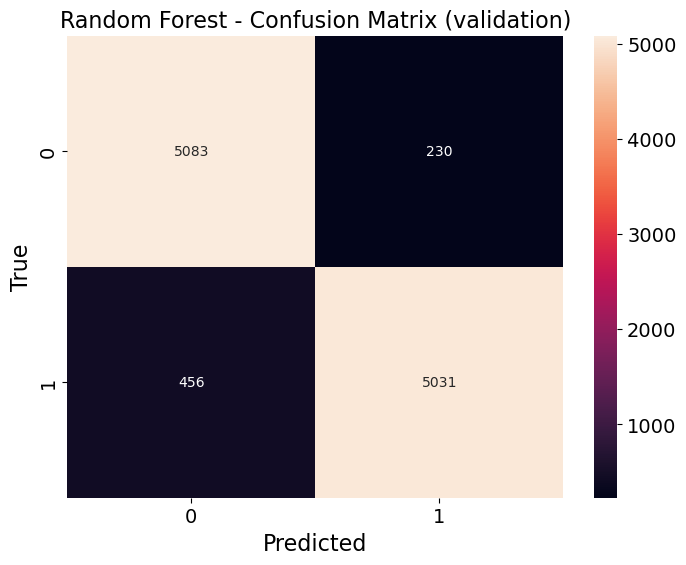


Classification Report [Random Forest] (validation):
Accuracy: 0.94
Precision: 0.96
Recall: 0.92
f-beta: 0.96


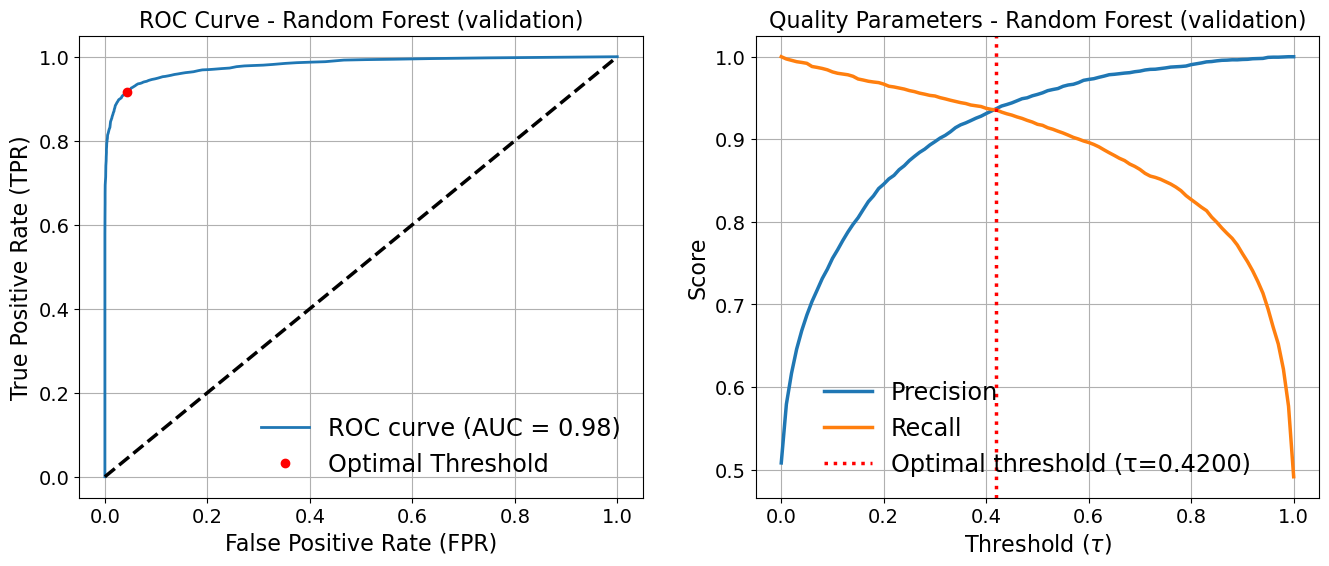

In [49]:
# Training and evaluation of Random Forest

model_name = "RF"
model = model_train_evaluate(model_name, X_train, y_train, X_val, y_val, False)

### RF Cross Validation

In [50]:
model_cross_validation(RandomForestClassifier(n_estimators = 100, random_state = 132), kf, X_train, y_train)

[Cross-Validation Results]
Average Accuracy:     0.9370 ± 0.0015
Average Precision:    0.9515 ± 0.0033
Average Recall:       0.9193 ± 0.0011
Average ROC AUC:      0.9813 ± 0.0005
Average F-beta (β=0.1): 0.9512 ± 0.0032


## k-Nearest Neighbors (kNN)

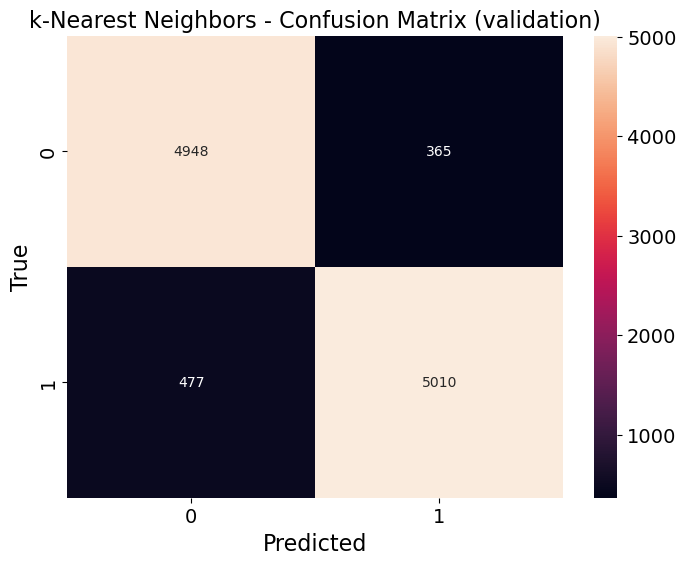


Classification Report [k-Nearest Neighbors] (validation):
Accuracy: 0.92
Precision: 0.93
Recall: 0.91
f-beta: 0.93


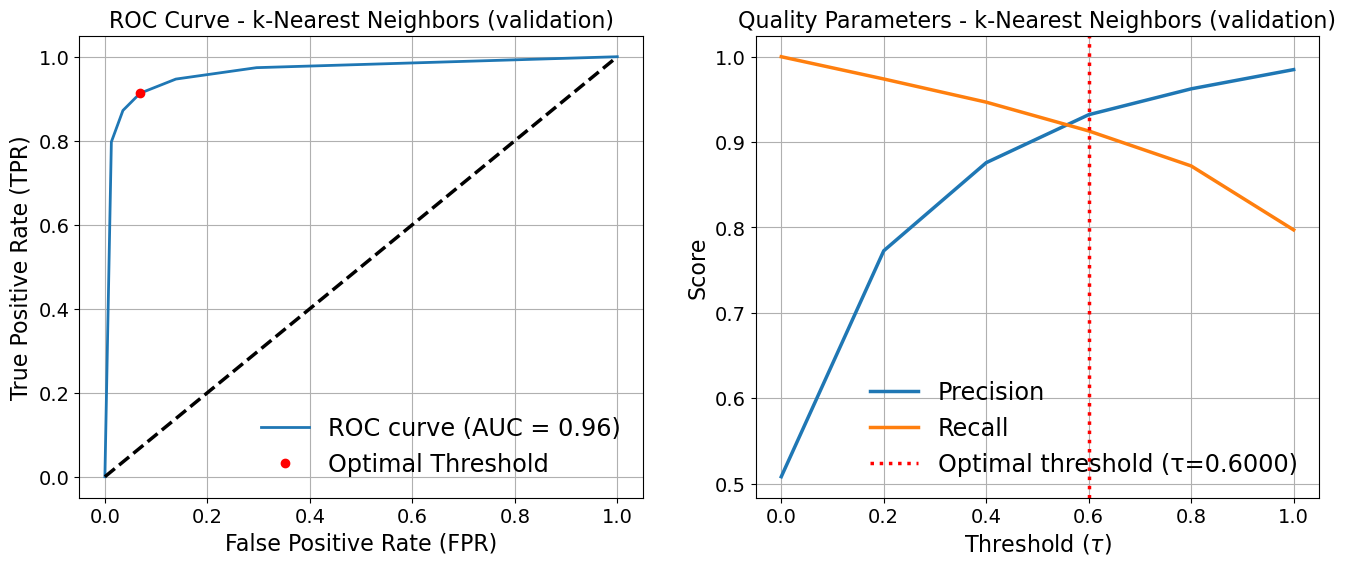

In [51]:
# Training and evaluation of kNN

model_name = "kNN"
model = model_train_evaluate(model_name, X_train, y_train, X_val, y_val, False)

### kNN Cross Validation

In [52]:
model_cross_validation(KNeighborsClassifier(n_neighbors=5), kf, X_train, y_train)

[Cross-Validation Results]
Average Accuracy:     0.8720 ± 0.0025
Average Precision:    0.8680 ± 0.0036
Average Recall:       0.8736 ± 0.0028
Average ROC AUC:      0.9311 ± 0.0015
Average F-beta (β=0.1): 0.8680 ± 0.0036
